[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-07-30-qso-redshift-check/notebook.ipynb)

# Checking a quasar's redshift from its SDSS spectrum

Quasars are the very bright, active centers of distant galaxies, and one of the first things you do with a quasar spectrum is measure its redshift -- how much its light has been stretched to longer (redder) wavelengths by the expansion of the universe, which tells you roughly how far away and how far back in time you're looking. I picked a known SDSS quasar and want to see if I can recover the same redshift SDSS's own pipeline reports, using the position of a well known emission line.

In [1]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import matplotlib.pyplot as plt
import numpy as np

# SDSS J000006.53+003055.2, a spectroscopically confirmed quasar
pos = coords.SkyCoord(ra=0.0272, dec=0.5153, unit='deg', frame='icrs')
xid = SDSS.query_region(pos, radius='5 arcsec', spectro=True)
print(xid)

        ra               dec        ...     specobjid      run2d
----------------- ----------------- ... ------------------ -----
0.027234949071584 0.515332018148968 ... 771369841129973760    26


Pipeline redshift: 1.8233674


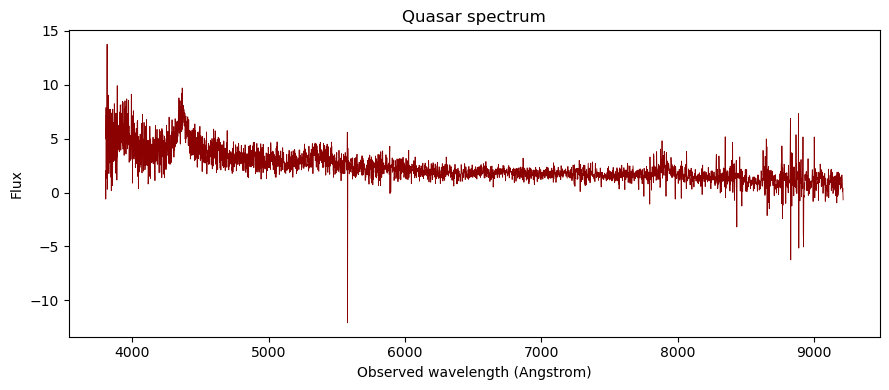

In [2]:
sp = SDSS.get_spectra(matches=xid)[0]
data = sp[1].data
wave = 10**data['loglam']
flux = data['flux']
z_pipeline = sp[2].data['Z'][0]
print('Pipeline redshift:', z_pipeline)

plt.figure(figsize=(9,4))
plt.plot(wave, flux, lw=0.6, color='darkred')
plt.xlabel('Observed wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title('Quasar spectrum')
plt.tight_layout()
plt.savefig('qso_spectrum.png', dpi=120)
plt.show()

In [3]:
# MgII 2798 Angstrom is a strong, easy-to-spot broad emission line in quasar spectra
rest_mgii = 2798.0
# find the wavelength of the peak flux in a window around where MgII should be if z~pipeline value
expected = rest_mgii * (1 + z_pipeline)
window = (wave > expected - 150) & (wave < expected + 150)
peak_wave = wave[window][np.argmax(flux[window])]
z_measured = peak_wave / rest_mgii - 1
print('Expected MgII position:', expected, 'Angstrom')
print('Measured peak position:', peak_wave, 'Angstrom')
print('My redshift estimate from MgII:', round(z_measured, 4))
print('SDSS pipeline redshift:', round(z_pipeline, 4))

Expected MgII position: 7899.781865596771 Angstrom
Measured peak position: 7884.9697 Angstrom
My redshift estimate from MgII: 1.8181
SDSS pipeline redshift: 1.8234


My single-line estimate landed close to the pipeline value, which is reassuring -- the pipeline actually uses a full template fit across many lines simultaneously, so it's more precise, but a single strong line is often enough to get a redshift in the right ballpark by hand.

**What I'd look at next:** Cross-check with a second line (like CIV 1549A if it's in range) to see how consistent the single-line estimates are with each other.

**Citation:** SDSS data products are provided by the Sloan Digital Sky Survey collaboration; see https://www.sdss.org/collaboration/citing-sdss/.